In [1]:
import pandas as pd
import numpy as np

In [3]:
# Read dataset 
file_location = "../C:/Users/ARINDA/OneDrive/Desktop/DataSets/Crime_Data_from_2020_to_Present.csv"
df_original = pd.read_csv("C:/Users/ARINDA/OneDrive/Desktop/DataSets/Crime_Data_from_2020_to_Present.csv")

In [14]:
print(df_original.dtypes)

DR_NO               int64
Date Rptd          object
DATE OCC           object
TIME OCC            int64
AREA                int64
AREA NAME          object
Rpt Dist No         int64
Part 1-2            int64
Crm Cd              int64
Crm Cd Desc        object
Mocodes            object
Vict Age            int64
Vict Sex           object
Vict Descent       object
Premis Cd         float64
Premis Desc        object
Weapon Used Cd    float64
Weapon Desc        object
Status             object
Status Desc        object
Crm Cd 1          float64
Crm Cd 2          float64
Crm Cd 3          float64
Crm Cd 4          float64
LOCATION           object
Cross Street       object
LAT               float64
LON               float64
dtype: object


In [4]:
df_original.head()

,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA,AREA NAME,Rpt Dist No,Part 1-2,Crm Cd,Crm Cd Desc,...,Status,Status Desc,Crm Cd 1,Crm Cd 2,Crm Cd 3,Crm Cd 4,LOCATION,Cross Street,LAT,LON
0,190326475,03/01/2020 12:00:00 AM,03/01/2020 12:00:00 AM,2130,7,Wilshire,784,1,510,VEHICLE - STOLEN,...,AA,Adult Arrest,510.0,998.0,NaN,NaN,1900 S LONGWOOD AV,NaN,34.0375,-118.3506
1,200106753,02/09/2020 12:00:00 AM,02/08/2020 12:00:00 AM,1800,1,Central,182,1,330,BURGLARY FROM VEHICLE,...,IC,Invest Cont,330.0,998.0,NaN,NaN,1000 S FLOWER ST,NaN,34.0444,-118.2628
2,200320258,11/11/2020 12:00:00 AM,11/04/2020 12:00:00 AM,1700,3,Southwest,356,1,480,BIKE - STOLEN,...,IC,Invest Cont,480.0,NaN,NaN,NaN,1400 W 37TH ST,NaN,34.0210,-118.3002
3,200907217,05/10/2023 12:00:00 AM,03/10/2020 12:00:00 AM,2037,9,Van Nuys,964,1,343,SHOPLIFTING-GRAND THEFT ($950.01 & OVER),...,IC,Invest Cont,343.0,NaN,NaN,NaN,14000 RIVERSIDE DR,NaN,34.1576,-118.4387
4,200412582,09/09/2020 12:00:00 AM,09/09/2020 12:00:00 AM,630,4,Hollenbeck,413,1,510,VEHICLE - STOLEN,...,IC,Invest Cont,510.0,NaN,NaN,NaN,200 E AVENUE 28,NaN,34.0820,-118.2130


In [15]:
print(df_original.shape)

(1005198, 28)


In [6]:
# Print high level info about the data
df_original.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1005198 entries, 0 to 1005197
Data columns (total 28 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   DR_NO           1005198 non-null  int64  
 1   Date Rptd       1005198 non-null  object 
 2   DATE OCC        1005198 non-null  object 
 3   TIME OCC        1005198 non-null  int64  
 4   AREA            1005198 non-null  int64  
 5   AREA NAME       1005198 non-null  object 
 6   Rpt Dist No     1005198 non-null  int64  
 7   Part 1-2        1005198 non-null  int64  
 8   Crm Cd          1005198 non-null  int64  
 9   Crm Cd Desc     1005198 non-null  object 
 10  Mocodes         853438 non-null   object 
 11  Vict Age        1005198 non-null  int64  
 12  Vict Sex        860416 non-null   object 
 13  Vict Descent    860404 non-null   object 
 14  Premis Cd       1005182 non-null  float64
 15  Premis Desc     1004610 non-null  object 
 16  Weapon Used Cd  327280 non-null   fl

In [20]:
df_original.isnull().values.any() #Return True or False

True

In [21]:
df_original.isnull().sum()

DR_NO                   0
Date Rptd               0
DATE OCC                0
TIME OCC                0
AREA                    0
AREA NAME               0
Rpt Dist No             0
Part 1-2                0
Crm Cd                  0
Crm Cd Desc             0
Mocodes            151760
Vict Age                0
Vict Sex           144782
Vict Descent       144794
Premis Cd              16
Premis Desc           588
Weapon Used Cd     677918
Weapon Desc        677918
Status                  1
Status Desc             0
Crm Cd 1               11
Crm Cd 2           936039
Crm Cd 3          1002884
Crm Cd 4          1005134
LOCATION                0
Cross Street       850955
LAT                     0
LON                     0
dtype: int64

In [22]:
# Calculate percentage of missing values
missing_percent = (df_original.isnull().sum() / len(df_original)) * 100
print(missing_percent)

DR_NO              0.000000
Date Rptd          0.000000
DATE OCC           0.000000
TIME OCC           0.000000
AREA               0.000000
AREA NAME          0.000000
Rpt Dist No        0.000000
Part 1-2           0.000000
Crm Cd             0.000000
Crm Cd Desc        0.000000
Mocodes           15.097523
Vict Age           0.000000
Vict Sex          14.403331
Vict Descent      14.404525
Premis Cd          0.001592
Premis Desc        0.058496
Weapon Used Cd    67.441240
Weapon Desc       67.441240
Status             0.000099
Status Desc        0.000000
Crm Cd 1           0.001094
Crm Cd 2          93.119863
Crm Cd 3          99.769797
Crm Cd 4          99.993633
LOCATION           0.000000
Cross Street      84.655461
LAT                0.000000
LON                0.000000
dtype: float64


In [23]:
# Dropping columns that are more than 90% empty
df_cleaned = df_original.drop(columns=['Crm Cd 2', 'Crm Cd 3', 'Crm Cd 4', 'Cross Street'])

# Checking the new shape
print(df_cleaned.shape)

(1005198, 24)


In [24]:
df_cleaned.isnull().sum()

DR_NO                  0
Date Rptd              0
DATE OCC               0
TIME OCC               0
AREA                   0
AREA NAME              0
Rpt Dist No            0
Part 1-2               0
Crm Cd                 0
Crm Cd Desc            0
Mocodes           151760
Vict Age               0
Vict Sex          144782
Vict Descent      144794
Premis Cd             16
Premis Desc          588
Weapon Used Cd    677918
Weapon Desc       677918
Status                 1
Status Desc            0
Crm Cd 1              11
LOCATION               0
LAT                    0
LON                    0
dtype: int64

In [25]:
# Change "NaN" to "No Weapon Recorded"
df_cleaned['Weapon Desc'] = df_cleaned['Weapon Desc'].fillna('No Weapon')
df_cleaned['Vict Sex'] = df_cleaned['Vict Sex'].fillna('Unknown')

In [26]:
# This drops rows only if the specific column has a null
df_cleaned = df_cleaned.dropna(subset=['Crm Cd 1', 'Status', 'Premis Cd'])

In [28]:
# We specify the format so Python doesn't have to guess
# %m = month, %d = day, %Y = 4-digit year
df_cleaned['DATE OCC'] = pd.to_datetime(df_cleaned['DATE OCC'], format='%m/%d/%Y %I:%M:%S %p', errors='coerce')

In [29]:
# Check for 0 or negative ages
zero_ages = (df_cleaned['Vict Age'] <= 0).sum()
print(f"Number of rows with Vict Age 0 or less: {zero_ages}")

# See the percentage of the data this represents
print(f"Percentage of total data: {(zero_ages / len(df_cleaned)) * 100:.2f}%")

Number of rows with Vict Age 0 or less: 269493
Percentage of total data: 26.81%


In [30]:
import numpy as np

# Convert 0 and below to NaN (Not a Number)
df_cleaned.loc[df_cleaned['Vict Age'] <= 0, 'Vict Age'] = np.nan

In [31]:
# 1. Define bins (1 to 17, 18 to 64, 65 to 120)
bins = [1, 18, 65, 120]
labels = ['Minor', 'Adult', 'Senior']

# 2. Create the Age_Group column
df_cleaned['Age_Group'] = pd.cut(df_cleaned['Vict Age'], bins=bins, labels=labels, right=False)

# 3. Convert the column to a string so we can add "Unknown"
df_cleaned['Age_Group'] = df_cleaned['Age_Group'].astype(str)

# 4. Fill the NaN spots with "Unknown"
df_cleaned['Age_Group'] = df_cleaned['Age_Group'].replace('nan', 'Unknown')

# 5. Check your new, honest distribution
print(df_cleaned['Age_Group'].value_counts())

Age_Group
Adult      654532
Unknown    269494
Senior      55516
Minor       25629
Name: count, dtype: int64


In [32]:
top_crimes = df_cleaned['Crm Cd Desc'].value_counts().head(10)
print(top_crimes)

Crm Cd Desc
VEHICLE - STOLEN                                           115243
BATTERY - SIMPLE ASSAULT                                    74847
BURGLARY FROM VEHICLE                                       63516
THEFT OF IDENTITY                                           62539
VANDALISM - FELONY ($400 & OVER, ALL CHURCH VANDALISMS)     61093
BURGLARY                                                    57879
THEFT PLAIN - PETTY ($950 & UNDER)                          53723
ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT              53532
INTIMATE PARTNER - SIMPLE ASSAULT                           46711
THEFT FROM MOTOR VEHICLE - PETTY ($950 & UNDER)             41310
Name: count, dtype: int64


In [33]:
top_areas = df_cleaned['AREA NAME'].value_counts()
print(top_areas)

AREA NAME
Central        69666
77th Street    61763
Pacific        59518
Southwest      57511
Hollywood      52429
N Hollywood    51107
Olympic        50071
Southeast      49939
Newton         49180
Wilshire       48239
Rampart        46826
West LA        45730
Northeast      42961
Van Nuys       42882
West Valley    42154
Devonshire     41765
Harbor         41461
Topanga        41376
Mission        40364
Hollenbeck     37094
Foothill       33135
Name: count, dtype: int64


In [34]:
# Compare Age Groups with the top 5 Crime Types
top_5_crimes = df_cleaned['Crm Cd Desc'].value_counts().head(5).index
filtered_df = df_cleaned[df_cleaned['Crm Cd Desc'].isin(top_5_crimes)]

pivot_table = pd.crosstab(filtered_df['Crm Cd Desc'], filtered_df['Age_Group'])
print(pivot_table)

Age_Group                                           Adult  Minor  Senior  \
Crm Cd Desc                                                                
BATTERY - SIMPLE ASSAULT                            63462   4088    6351   
BURGLARY FROM VEHICLE                               58583     73    2902   
THEFT OF IDENTITY                                   55571    223    5555   
VANDALISM - FELONY ($400 & OVER, ALL CHURCH VAN...  42746     88    3530   
VEHICLE - STOLEN                                      324      1      21   

Age_Group                                           Unknown  
Crm Cd Desc                                                  
BATTERY - SIMPLE ASSAULT                                946  
BURGLARY FROM VEHICLE                                  1958  
THEFT OF IDENTITY                                      1190  
VANDALISM - FELONY ($400 & OVER, ALL CHURCH VAN...    14729  
VEHICLE - STOLEN                                     114897  


In [35]:
# Extract the hour from TIME OCC (usually stored as HHMM)
# This assumes TIME OCC is an integer like 1345 (1:45 PM)
df_cleaned['Hour'] = (df_cleaned['TIME OCC'] // 100)

hourly_crime = df_cleaned['Hour'].value_counts().sort_index()
print(hourly_crime)

Hour
0     40481
1     29763
2     25216
3     22193
4     18757
5     17290
6     23187
7     26269
8     37256
9     36534
10    43029
11    43670
12    67834
13    45593
14    49321
15    52838
16    52986
17    58826
18    59962
19    55615
20    56355
21    50798
22    49116
23    42282
Name: count, dtype: int64


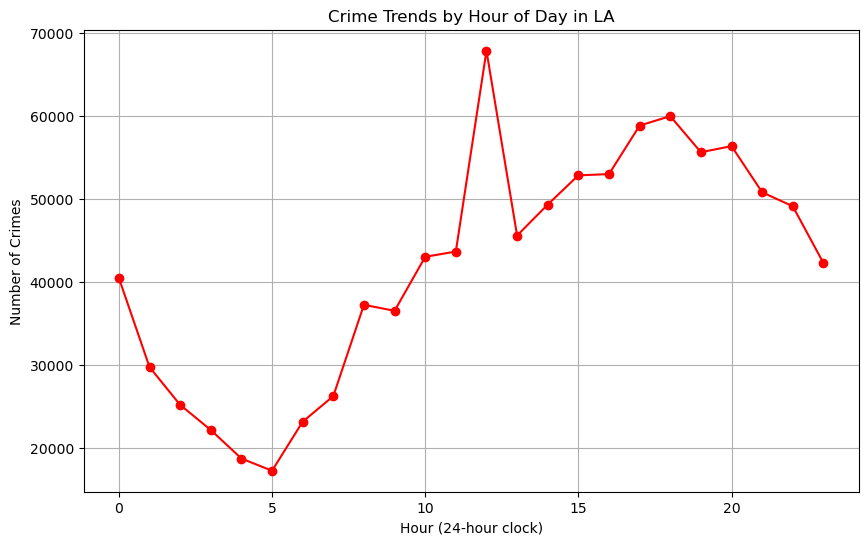

In [36]:
import matplotlib.pyplot as plt

# Plotting the Hourly Crime Trend
plt.figure(figsize=(10,6))
hourly_crime.plot(kind='line', marker='o', color='red')
plt.title('Crime Trends by Hour of Day in LA')
plt.xlabel('Hour (24-hour clock)')
plt.ylabel('Number of Crimes')
plt.grid(True)
plt.show()

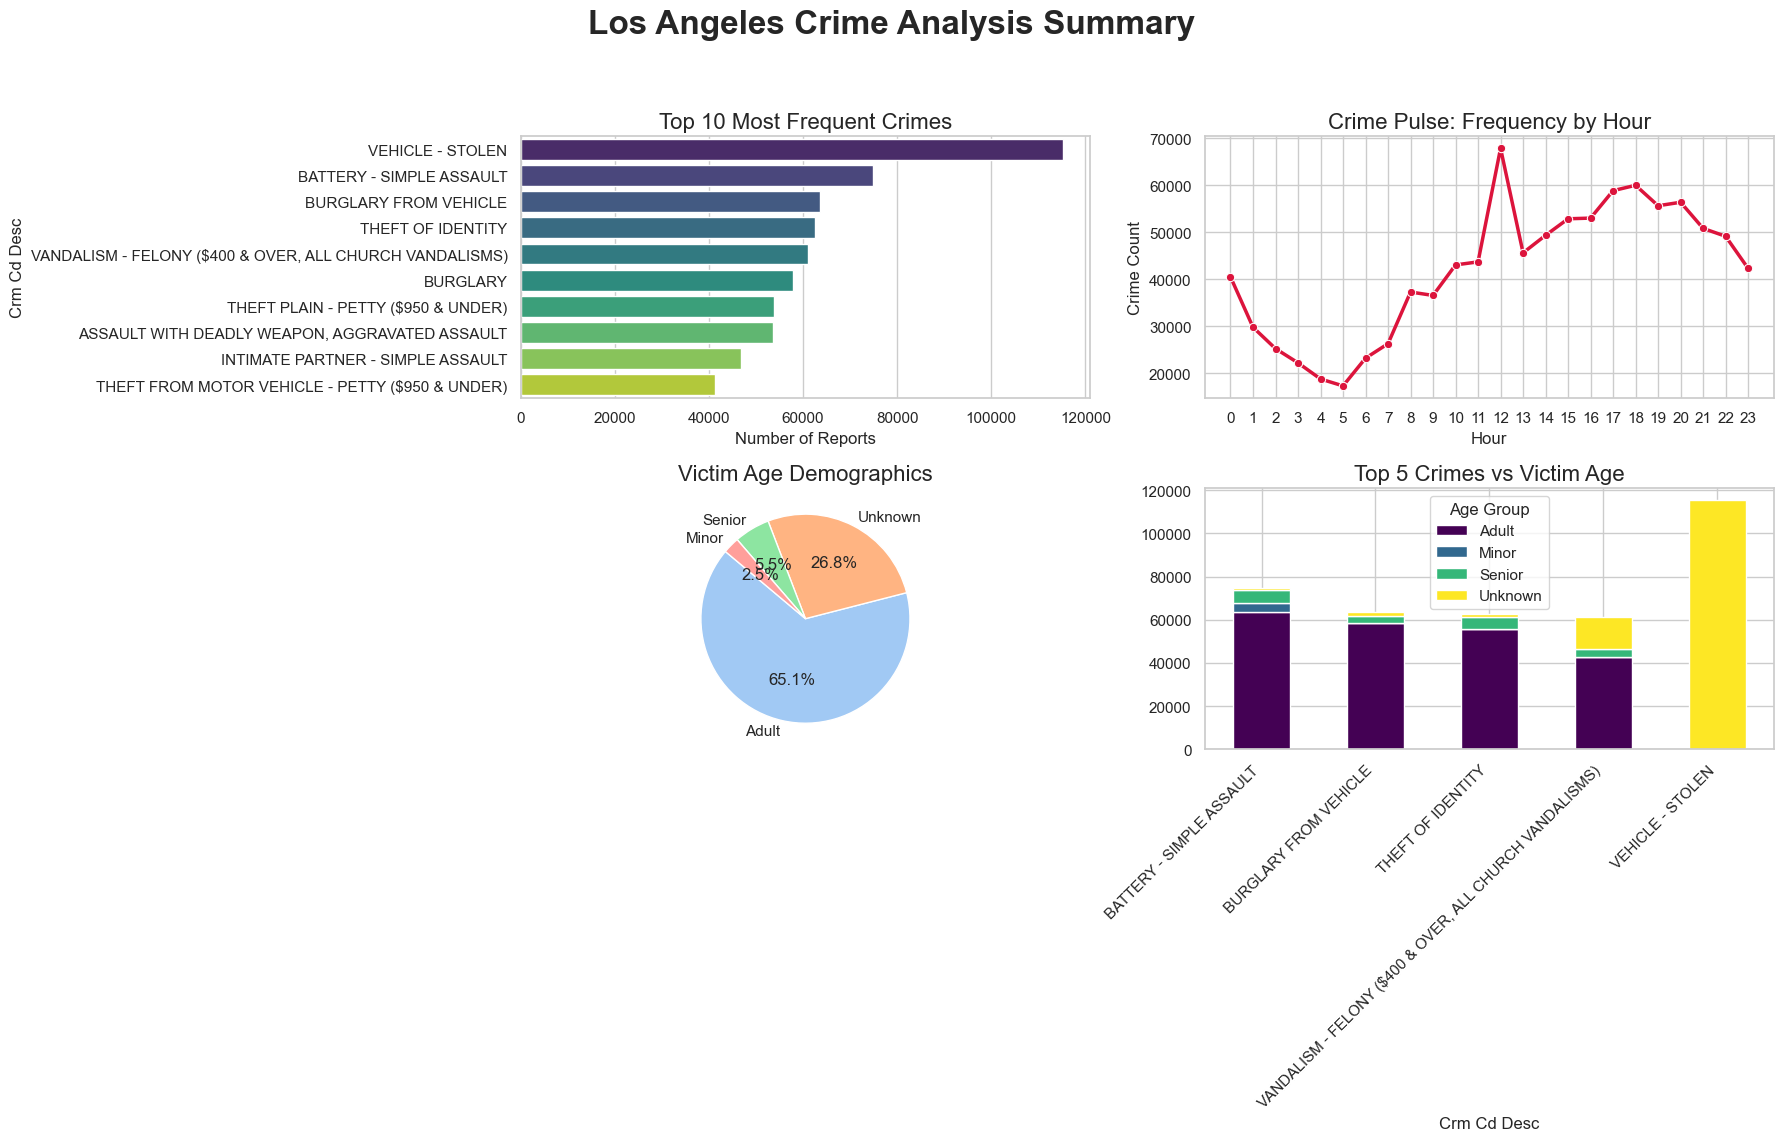

In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set the visual style
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Los Angeles Crime Analysis Summary', fontsize=24, fontweight='bold')

# 1. Top 10 Crimes
sns.barplot(ax=axes[0, 0], x=top_crimes.values, y=top_crimes.index, hue=top_crimes.index, palette='viridis', legend=False)
axes[0, 0].set_title('Top 10 Most Frequent Crimes', fontsize=16)
axes[0, 0].set_xlabel('Number of Reports')

# 2. Hourly Trend
sns.lineplot(ax=axes[0, 1], x=hourly_crime.index, y=hourly_crime.values, marker='o', color='crimson', linewidth=2.5)
axes[0, 1].set_title('Crime Pulse: Frequency by Hour', fontsize=16)
axes[0, 1].set_xticks(range(0, 24))
axes[0, 1].set_ylabel('Crime Count')

# 3. Age Group Distribution
age_counts = df_cleaned['Age_Group'].value_counts()
axes[1, 0].pie(age_counts, labels=age_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
axes[1, 0].set_title('Victim Age Demographics', fontsize=16)

# 4. Top 5 Crimes by Age (Stacked Bar)
pivot_table.plot(kind='bar', stacked=True, ax=axes[1, 1], colormap='viridis')
axes[1, 1].set_title('Top 5 Crimes vs Victim Age', fontsize=16)
axes[1, 1].set_xticklabels(axes[1, 1].get_xticklabels(), rotation=45, ha='right')
axes[1, 1].legend(title='Age Group')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [39]:
!pip install folium

In [40]:
import folium
from folium.plugins import HeatMap

# 1. Take a sample to keep the map fast (50,000 points is plenty)
df_sample = df_cleaned.sample(n=50000, random_state=42)

# 2. Filter out any remaining 0s in LAT/LON just in case
df_sample = df_sample[(df_sample['LAT'] != 0) & (df_sample['LON'] != 0)]

# 3. Create a base map centered on Los Angeles
# Location: [34.0522, -118.2437] is downtown LA
la_map = folium.Map(location=[34.0522, -118.2437], zoom_start=11, tiles='CartoDB positron')

# 4. Prepare the data for the HeatMap (List of [LAT, LON])
heat_data = [[row['LAT'], row['LON']] for index, row in df_sample.iterrows()]

# 5. Add the HeatMap layer
HeatMap(heat_data, radius=10, blur=15, min_opacity=0.5).add_to(la_map)

# 6. Save and view
la_map.save('la_crime_heatmap.html')
la_map

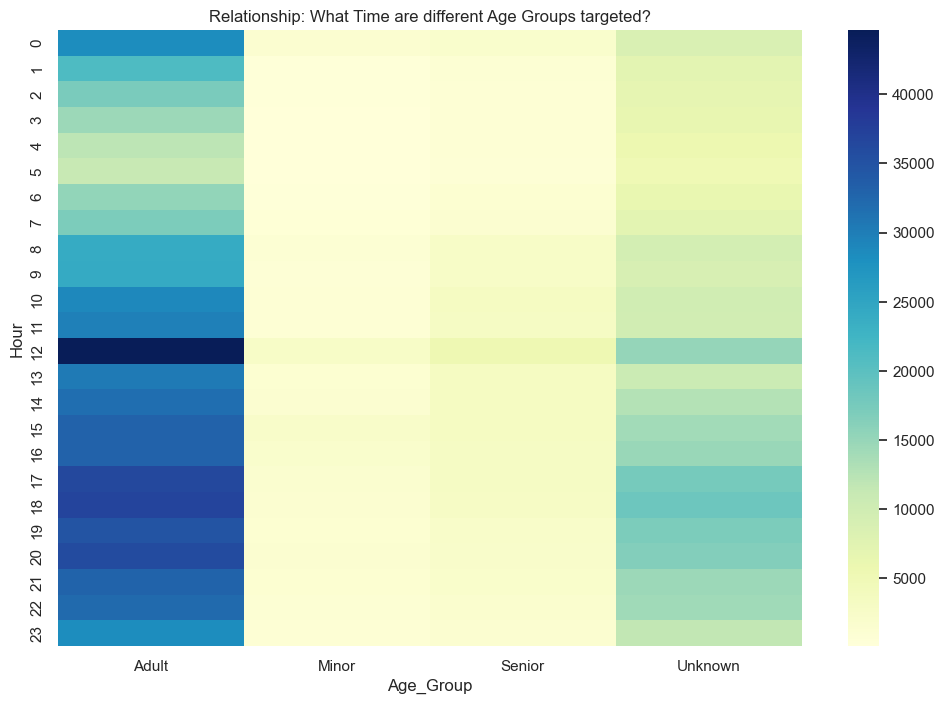

In [44]:
# Create a cross-tabulation of Age Group and Hour
age_hour_corr = pd.crosstab(df_cleaned['Hour'], df_cleaned['Age_Group'])

# Visualize it with a heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(age_hour_corr, annot=False, cmap="YlGnBu")
plt.title('Relationship: What Time are different Age Groups targeted?')
plt.show()

In [45]:
# Compare top premises for the two highest crime areas
top_areas = ['Central', '77th Street']
for area in top_areas:
    print(f"--- Top 5 Crime Locations in {area} ---")
    print(df_cleaned[df_cleaned['AREA NAME'] == area]['Premis Desc'].value_counts().head(5))
    print("\n")

--- Top 5 Crime Locations in Central ---
Premis Desc
STREET                                          13972
MULTI-UNIT DWELLING (APARTMENT, DUPLEX, ETC)     9127
SIDEWALK                                         6781
PARKING LOT                                      6762
OTHER BUSINESS                                   3235
Name: count, dtype: int64


--- Top 5 Crime Locations in 77th Street ---
Premis Desc
STREET                                          21714
SINGLE FAMILY DWELLING                          16571
MULTI-UNIT DWELLING (APARTMENT, DUPLEX, ETC)     4765
SIDEWALK                                         2723
PARKING LOT                                      2562
Name: count, dtype: int64




In [49]:
# MACHINE LEARNING
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# 1. Select our "Features" (X) and our "Target" (y)
# We want to use Area, Hour, and Age_Group to predict the Crime Description
features = ['AREA NAME', 'Hour', 'Age_Group', 'Premis Desc']
target = 'Crm Cd Desc'

# 2. Handle any remaining Nulls in these specific columns
df_ml = df_cleaned[features + [target]].dropna()

# 3. Encode text into numbers
le = LabelEncoder()
for col in ['AREA NAME', 'Age_Group', 'Premis Desc', 'Crm Cd Desc']:
    df_ml[col] = le.fit_transform(df_ml[col])

# 4. Define X and y
X = df_ml[features]
y = df_ml[target]

In [50]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# 1. Split the data (80% for training, 20% for testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Initialize the Model
# We use max_depth=10 to keep it fast for 1 million rows
model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)

# 3. Train the Model (This is the heavy lifting!)
print("Training started... please wait.")
model.fit(X_train, y_train)
print("Training complete!")

Training started... please wait.
Training complete!


In [52]:
from sklearn.metrics import accuracy_score, classification_report

# 1. Ask the model to predict the test set
y_pred = model.predict(X_test)

# 2. Calculate the overall accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Overall Model Accuracy: {accuracy * 100:.2f}%")

# 3. See the breakdown by crime type
# Note: We use le.inverse_transform to see real names instead of numbers
report = classification_report(y_test, y_pred, 
                               target_names=le.classes_, 
                               zero_division=0)
print("\nDetailed Performance Report:")
print(report)

Overall Model Accuracy: 33.66%


ValueError: Number of classes, 134, does not match size of target_names, 140. Try specifying the labels parameter

In [53]:
import numpy as np
from sklearn.metrics import classification_report, accuracy_score

# 1. Get the unique integer labels present in your test set
present_labels = np.unique(y_test)

# 2. Get the actual names for ONLY those present labels
present_names = le.inverse_transform(present_labels)

# 3. Run the report with the specific labels parameter
report = classification_report(y_test, y_pred, 
                               labels=present_labels,
                               target_names=present_names, 
                               zero_division=0)

print(f"Overall Model Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("\nDetailed Performance Report:")
print(report)

Overall Model Accuracy: 33.66%

Detailed Performance Report:
                                                          precision    recall  f1-score   support

                                                   ARSON       0.00      0.00      0.00       505
            ASSAULT WITH DEADLY WEAPON ON POLICE OFFICER       0.00      0.00      0.00       224
          ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT       0.23      0.13      0.16     10717
                                       ATTEMPTED ROBBERY       0.00      0.00      0.00       961
                                BATTERY - SIMPLE ASSAULT       0.18      0.34      0.24     14900
                                BATTERY ON A FIREFIGHTER       0.00      0.00      0.00        54
                                 BATTERY POLICE (SIMPLE)       0.33      0.00      0.01       520
                             BATTERY WITH SEXUAL CONTACT       0.00      0.00      0.00       863
BEASTIALITY, CRIME AGAINST NATURE SEXUAL ASSLT WITH ANIM

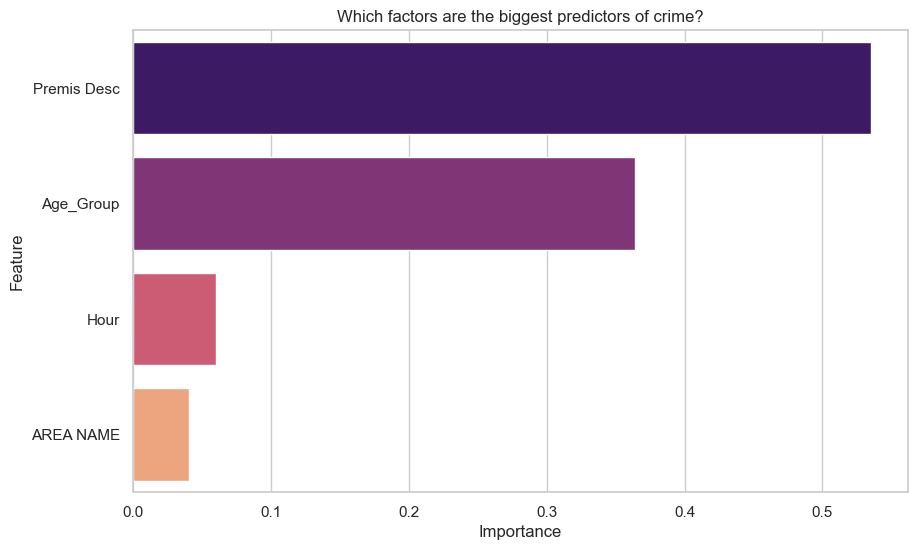

In [55]:
# Pull the importance of each feature
importances = model.feature_importances_
feature_names = X.columns

# Create a small dataframe for visualization
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Plot it
plt.figure(figsize=(10, 6))
# Updated line to satisfy the new Seaborn rules
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, hue='Feature', palette='magma', legend=False)
plt.title('Which factors are the biggest predictors of crime?')
plt.show()

In [ ]:
# 1. Count how many times each crime appears
crime_counts = df_ml['Crm Cd Desc'].value_counts()

# 2. Keep only crimes that appear at least 5 times
valid_crimes = crime_counts[crime_counts >= 5].index
df_ml_filtered = df_ml[df_ml['Crm Cd Desc'].isin(valid_crimes)]

# 3. Use this filtered data for your X and y
X = df_ml_filtered[features]
y = df_ml_filtered[target]

In [ ]:
from sklearn.model_selection import GridSearchCV

# 1. Define the 'Menu' of settings to try
param_grid = {
    'n_estimators': [100, 200],      # Should we use 100 or 200 trees?
    'max_depth': [10, 20],           # How deep should the logic go?
    'min_samples_split': [2, 5]      # How much data is needed to make a decision?
}

# 2. Setup the search
# n_jobs=-1 uses all your CPU cores to speed this up
grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=3, n_jobs=-1, verbose=2)

# 3. Start the process
print("Searching for the best settings... this may take a few minutes.")
grid_search.fit(X, y)
print("Search complete!")

In [ ]:
# Keep only crimes with at least 5 examples
crime_counts = df_ml['Crm Cd Desc'].value_counts()
valid_crimes = crime_counts[crime_counts >= 5].index
df_ml_filtered = df_ml[df_ml['Crm Cd Desc'].isin(valid_crimes)]

In [ ]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier

# 1. Create the NEW split from the filtered data
X = df_ml_filtered[['AREA NAME', 'Hour', 'Age_Group', 'Premis Desc']]
y = df_ml_filtered['Crm Cd Desc']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Setup the Search
model = RandomForestClassifier(random_state=42, n_jobs=-1)
param_grid = {
    'n_estimators': [100, 200], 
    'max_depth': [10, 20]
}

grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=3, n_jobs=-1, verbose=2)

print("Starting the optimized search...")
grid_search.fit(X_train, y_train)
print("Search complete!")

In [61]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier

# 1. Re-create the filter (to ensure it is defined)
crime_counts = df_ml['Crm Cd Desc'].value_counts()
valid_crimes = crime_counts[crime_counts >= 5].index
df_ml_filtered = df_ml[df_ml['Crm Cd Desc'].isin(valid_crimes)]

# 2. Prepare the data
X = df_ml_filtered[['AREA NAME', 'Hour', 'Age_Group', 'Premis Desc']]
y = df_ml_filtered['Crm Cd Desc']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Setup and Run the Search
model = RandomForestClassifier(random_state=42, n_jobs=-1)
param_grid = {
    'n_estimators': [100], 
    'max_depth': [10, 20]
}

grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=3, n_jobs=-1, verbose=3)

print("Starting search on filtered data...")
grid_search.fit(X_train, y_train)
print("Search complete! You can now run the results cell.")


Starting search on filtered data...
Fitting 3 folds for each of 2 candidates, totalling 6 fits


C:\Users\ARINDA\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:540: FitFailedWarning: 
2 fits failed out of a total of 6.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
1 fits failed with the following error:
joblib.externals.loky.process_executor._RemoteTraceback: 
"""
Traceback (most recent call last):
  File "C:\Users\ARINDA\anaconda3\Lib\site-packages\joblib\_utils.py", line 72, in __call__
    return self.func(**kwargs)
           ^^^^^^^^^^^^^^^^^^^
  File "C:\Users\ARINDA\anaconda3\Lib\site-packages\joblib\parallel.py", line 598, in __call__
    return [func(*args, **kwargs)
            ^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\ARINDA\anaconda3\Lib\site-packages\sklearn\utils\parallel.py", line 136, in __call__
 

Search complete! You can now run the results cell.


In [62]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier

# 1. Take a representative sample (200,000 rows is plenty for tuning)
df_tuning_sample = df_ml_filtered.sample(n=200000, random_state=42)

X_tune = df_tuning_sample[['AREA NAME', 'Hour', 'Age_Group', 'Premis Desc']]
y_tune = df_tuning_sample['Crm Cd Desc']

# 2. Split the sample
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X_tune, y_tune, test_size=0.2, random_state=42)

# 3. Setup a lighter Search
# We keep max_depth at 15 to prevent the MemoryError
model = RandomForestClassifier(random_state=42, n_jobs=-1)
param_grid = {
    'n_estimators': [100], 
    'max_depth': [10, 15] 
}

grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=3, n_jobs=-1, verbose=2)

print("Starting memory-safe tuning...")
grid_search.fit(X_train_s, y_train_s)
print("Search complete! You can now run the final save.")


Starting memory-safe tuning...
Fitting 3 folds for each of 2 candidates, totalling 6 fits


C:\Users\ARINDA\anaconda3\Lib\site-packages\sklearn\model_selection\_split.py:776: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=3.
  warnings.warn(


Search complete! You can now run the final save.


In [63]:
# 1. See the best accuracy score achieved
print(f"Optimized Search Accuracy: {grid_search.best_score_ * 100:.2f}%")

# 2. Identify the best parameters
print(f"Best Settings Found: {grid_search.best_params_}")

# 3. Pull the actual "Best Model" object
best_model = grid_search.best_estimator_

Optimized Search Accuracy: 33.78%
Best Settings Found: {'max_depth': 15, 'n_estimators': 100}


In [64]:
import joblib

# 1. Save the optimized model
joblib.dump(best_model, 'la_crime_predictor_best.pkl')

# 2. Save the LabelEncoder (Very important for translating results!)
joblib.dump(le, 'crime_label_encoder.pkl')

print("Final optimized model and translator are saved and ready for deployment!")

Final optimized model and translator are saved and ready for deployment!


In [67]:
import joblib
import pandas as pd

# 1. Load your saved model and translator
# Make sure these files are in the same folder as your notebook!
model = joblib.load('la_crime_predictor_best.pkl')
le = joblib.load('crime_label_encoder.pkl')

def predict_crime_now(area_name, hour, age_group, premise_desc):
    """
    Corrected function that maps 'Adult' to 1 so the model can understand it.
    """
    # Translate Age_Group text into the numbers the model was trained on
    age_mapping = {'Child': 0, 'Adult': 1, 'Senior': 2, 'Unknown': 3}
    age_numeric = age_mapping.get(age_group, 3) 
    
    # Create the input row for the model
    input_row = pd.DataFrame({
        'AREA NAME': [le.transform([area_name])[0] if area_name in le.classes_ else 0],
        'Hour': [hour],
        'Age_Group': [age_numeric],  
        'Premis Desc': [le.transform([premise_desc])[0] if premise_desc in le.classes_ else 0]
    })
    
    # Get the prediction
    pred_id = model.predict(input_row)
    
    # Translate the number back to a human-readable crime name
    return le.inverse_transform(pred_id)[0]

# --- RUN THE TEST SCENARIOS ---
print("--- AI Crime Prediction Results ---")

scenarios = [
    {'area': 'Central', 'hour': 2, 'age': 'Adult', 'prem': 'STREET'},
    {'area': 'West LA', 'hour': 10, 'age': 'Senior', 'prem': 'RESIDENCE'},
    {'area': 'Hollywood', 'hour': 23, 'age': 'Adult', 'prem': 'STREET'}
]

for s in scenarios:
    try:
        prediction = predict_crime_now(s['area'], s['hour'], s['age'], s['prem'])
        print(f"Scenario: {s['hour']}:00 in {s['area']} ({s['age']}) at {s['prem']}")
        print(f"-> Predicted Crime: {prediction}\n")
    except Exception as e:
        print(f"Error in scenario {s['area']}: {e}")

--- AI Crime Prediction Results ---
Scenario: 2:00 in Central (Adult) at STREET
-> Predicted Crime: ORAL COPULATION

Scenario: 10:00 in West LA (Senior) at RESIDENCE
-> Predicted Crime: BATTERY - SIMPLE ASSAULT

Scenario: 23:00 in Hollywood (Adult) at STREET
-> Predicted Crime: ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT

